In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import librosa
import soundfile
import torch
import torchaudio
from torchaudio import transforms as T
import librosa
import soundfile as sf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import sys
import os
sys.path.append('./dataset/cats_dogs_dataset')
import utils
import myutils
from myutils import Augmentation

print(torch.cuda.is_available())

True


#### Data Augmentation

In [2]:
dataset_path_train = f'dataset/talk_dataset/train/'
dataset_path_test = f'dataset/talk_dataset/test/'

# AUGMENTATION RUN ONCE ONLY #
# augmentator = Augmentation(noise_factor=0.001, time_shift_max=0.2, pitch_step=[2,-2], t_stretch_rate=1.2, volume_scale_factor=[1.5,-1.5])
# for folders in [f for f in os.listdir(dataset_path_train) if os.path.isdir(os.path.join(dataset_path_train, f))]:
#     for item in os.listdir(os.path.join(dataset_path_train, folders)):
#         y, sr = librosa.load(os.path.join(dataset_path_train, folders, item))

#         y_noise = augmentator.noise_inject(y)
#         sf.write(f'{dataset_path_train}{folders}/noise_{item}', y_noise, sr)

#         y_time_shift = augmentator.time_shift(y)
#         sf.write(f'{dataset_path_train}{folders}/ts_{item}', y_time_shift, sr)

#         y_pitch_shift = augmentator.pitch_shift(y, sr)
#         sf.write(f'{dataset_path_train}{folders}/ps_{item}', y_pitch_shift, sr)

#         y_time_stretch = augmentator.time_stretch(y)
#         sf.write(f'{dataset_path_train}{folders}/time_str_{item}', y_time_stretch, sr)

#         y_volume_scale = augmentator.volume_scale(y)
#         sf.write(f'{dataset_path_train}{folders}/vc_{item}', y_volume_scale, sr)
        

#### Feature Extraction

In [3]:
targets = ['ammar', 'aditya', 'faiszal']

def extract_rows(dataset_path):
    rows = []
    for folder in [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]:
        for item in os.listdir(os.path.join(dataset_path, folder)):
            feat = myutils.feature_extraction(os.path.join(dataset_path, folder, item))
            
            # Flatten MFCC features
            for prefix, key in [("mfcc_mean", "mean_mfcc"), ("mfcc_std", "std_mfcc")]:
                for i, v in enumerate(feat.pop(key), start=1):
                    feat[f"{prefix}_{i}"] = v
            
            # Assign target label
            feat['target'] = next(
                (i for i, t in enumerate(targets) if t in item), None
            )
            rows.append(feat)
    
    return pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

extracted_train = extract_rows(dataset_path_train)
extracted_test  = extract_rows(dataset_path_test)

In [4]:
extracted_train.head()

,mean,std,max,min,median,rms,zcr,centroid_mean,centroid_std,centroid_min,...,mfcc_std_5,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,target
0,0.000010,0.030764,0.303001,-0.324950,-0.000083,0.030764,0.161670,2187.654310,971.749001,340.145247,...,12.835220,8.341743,13.234012,10.676108,10.232020,8.998405,8.298804,5.617096,10.975471,1
1,-0.000015,0.044712,0.301133,-0.259235,-0.000094,0.044712,0.104182,1519.612455,814.053991,380.537725,...,15.408545,9.532901,11.832510,7.343838,7.922593,6.120629,9.862781,8.110394,6.749180,2
2,-0.000037,0.027072,0.280635,-0.215081,-0.000299,0.027072,0.147847,2093.751660,982.939902,356.916022,...,16.294300,9.704599,11.637136,14.984998,10.977670,10.747743,11.065040,6.574115,8.762700,1
3,0.000021,0.033320,0.391325,-0.485079,-0.000057,0.033320,0.171485,2394.292221,968.097665,313.810051,...,15.347259,12.021238,10.672893,11.221241,8.188985,11.186193,7.180341,4.798026,10.872126,1
4,0.000017,0.049974,0.251528,-0.332002,0.000395,0.049974,0.112890,1503.222936,839.620253,558.908285,...,15.587585,17.072927,13.525639,12.627522,11.283851,12.197436,11.140726,8.497793,11.667485,0


In [5]:
extracted_test.head()

,mean,std,max,min,median,rms,zcr,centroid_mean,centroid_std,centroid_min,...,mfcc_std_5,mfcc_std_6,mfcc_std_7,mfcc_std_8,mfcc_std_9,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,target
0,-0.000015,0.036044,0.178796,-0.245488,-0.000049,0.036044,0.126731,1592.426720,766.975699,742.792559,...,16.728231,11.308041,9.658313,12.287599,8.084688,9.584631,9.043214,6.800853,8.531385,0
1,0.000033,0.066775,0.307905,-0.333683,0.000427,0.066775,0.105117,1743.668002,770.065063,708.139862,...,18.057892,15.082083,9.838260,13.682545,14.032802,11.077582,13.988539,7.754812,9.810833,0
2,0.000009,0.041690,0.383650,-0.386894,-0.000325,0.041690,0.227376,2769.781178,1391.296584,558.615406,...,16.007738,25.580006,12.233568,11.536750,7.264686,13.879285,11.086481,8.786708,12.053644,1
3,0.000007,0.042663,0.373731,-0.326048,-0.000076,0.042663,0.110314,1622.168145,732.945242,674.348358,...,14.178223,12.533495,10.587734,12.938785,8.564506,11.303060,9.005997,7.393746,7.883412,0
4,-0.000002,0.027402,0.305344,-0.296792,-0.000146,0.027402,0.180458,2409.691102,747.251062,856.847473,...,11.451453,14.203949,10.234208,8.031529,7.129420,13.429274,7.861839,7.769296,9.641104,1


In [6]:
# from sklearn.inspection import permutation_importance

# result = permutation_importance(model_svm, X_test, y_test, n_repeats=30, random_state=42)

# # Tampilkan feature importance
# feature_names = extracted_train.drop(columns=['target']).columns.tolist()
# importance_df = pd.DataFrame({
#     'feature'   : feature_names,
#     'importance': result.importances_mean,
#     'std'       : result.importances_std
# }).sort_values('importance', ascending=False)

# print(importance_df.to_string(index=False))

#### Data Preprocess

In [7]:
scaler = StandardScaler()

X_train = extracted_train.drop(columns=['target'])
y_train = extracted_train['target']
X_test = extracted_test.drop(columns=['target'])
y_test = extracted_test['target']

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Training

In [8]:
# model_svm = SVC(kernel='poly')
# model_svm.fit(X_train, y_train)

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

         EVALUATION RESULTS
Accuracy  : 0.9756
Precision : 0.9762
Recall    : 0.9744
F1 Score  : 0.9743

Classification Report:
              precision    recall  f1-score   support

       ammar       1.00      0.92      0.96        13
      aditya       0.93      1.00      0.96        13
     faiszal       1.00      1.00      1.00        15

    accuracy                           0.98        41
   macro avg       0.98      0.97      0.97        41
weighted avg       0.98      0.98      0.98        41



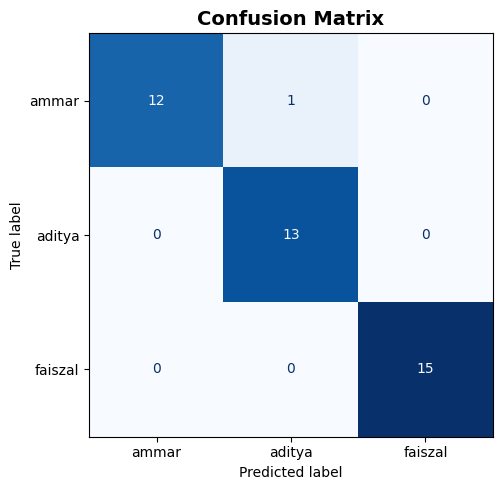

In [9]:
y_pred = model_rf.predict(X_test) 

print("=" * 40)
print("         EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ammar', 'aditya', 'faiszal']))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ammar', 'aditya', 'faiszal'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()